# [기초-실습] 통계 분석의 첫걸음: 통계학·모집단·기술통계

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비 — 한글 폰트 설치 및 라이브러리 불러오기

In [2]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [3]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
plt.rcParams['font.family'] = 'Malgun Gothic'

# 문제 1. 기초통계량 계산

**📘 문제**

- 온라인 쇼핑몰 고객 1,000명을 대상으로 1점부터 10점 사이의 만족도 조사를 실시했습니다.
  이 데이터를 바탕으로 고객 만족도의 **중심 경향성**과 **분포 특성**을 파악해 봅시다.

In [5]:
# 데이터 생성
np.random.seed(2025)
satisfaction = np.random.normal(7.5, 1.5, 1000)
satisfaction = np.clip(satisfaction, 1, 10)
df1 = pd.DataFrame({'score': satisfaction})
df1.head(5)

,score
0,7.361415
1,8.601428
2,5.341677
3,6.504867
4,7.348908


**📌 아래를 수행해 보세요:**

- 평균, 중앙값, 최빈값, 표준편차를 계산해 봅시다.
- 히스토그램을 그리고 평균과 중앙값 선으로 표시해 봅시다.
- 데이터의 분포 형태를 해석한 후, 마케팅 전략 수립에 어떻게 활용할 수 있을지 생각해 봅시다.

평균: 7.43
중앙값: 7.42
최빈값: 10.00
표준편차: 1.39


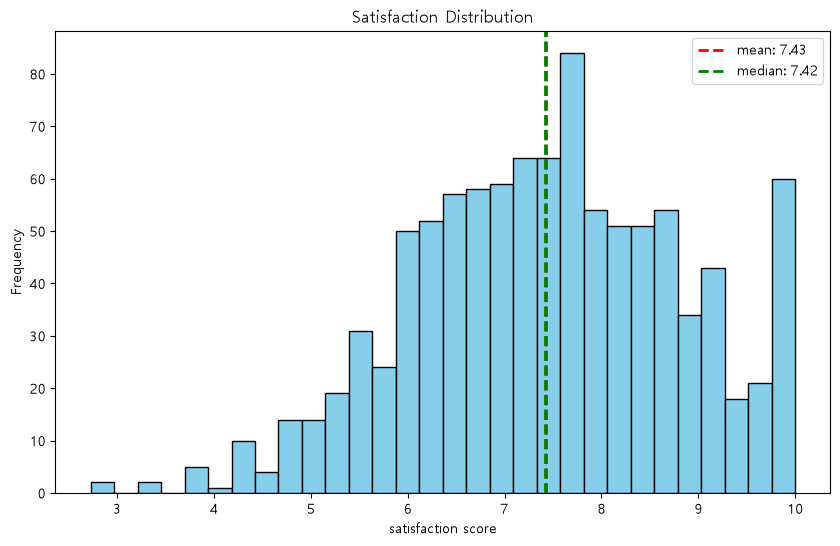


마케팅 활용방안: 
점수는 평균 7.5, 표준편차 1.5의 종모양 분포로, 대다수가 6~9점대에 몰려있다. 
6점 미만/9점 이상으로 저점수군·고점수군을 나눠 각각 불만 원인과 만족 요인을 분석하면, 저점수군엔 타겟 개선책을, 고점수군엔 리텐션(재방문) 전략을 적용할 수 있다.


In [16]:
# 아래를 수행해 보세요:
# [문제 1] 여기에 코드를 작성해주세요.
# 평균, 중앙값, 최빈값, 표준편차 계산
mean_val = df1['score'].mean()
median_val = df1['score'].median()
mode_val = df1['score'].mode()[0]
std_val = df1['score'].std()

print(f"평균: {mean_val:.2f}")
print(f"중앙값: {median_val:.2f}")
print(f"최빈값: {mode_val:.2f}")
print(f"표준편차: {std_val:.2f}")

# 히스토그램 그리기
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df1['score'], bins=30, color='skyblue', edgecolor='black')

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'median: {median_val:.2f}')

plt.title('Satisfaction Distribution')
plt.xlabel('satisfaction score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print()
print('마케팅 활용방안: \n점수는 평균 7.5, 표준편차 1.5의 종모양 분포로, 대다수가 6~9점대에 몰려있다. \n6점 미만/9점 이상으로 저점수군·고점수군을 나눠 각각 불만 원인과 만족 요인을 분석하면, 저점수군엔 타겟 개선책을, 고점수군엔 리텐션(재방문) 전략을 적용할 수 있다.')

**🧠 데이터를 어떻게 읽을까요?**

1. 평균과 중앙값 사이의 차이는 어느 정도인가요?
   - 두 값이 비슷하다면, 이 데이터는 어떤 분포 형태일 가능성이 있을까요? (예: 대칭형, 정규분포 등)
   - 두 값의 차이가 크다면, 그 이유는 무엇일까요?
   - 어떤 값들이 평균을 끌어내리거나 끌어올렸을까요?

2. 최빈값이 평균보다 낮은 경우, 낮은 점수를 준 고객이 많다는 뜻일 수 있습니다. 이 경우 데이터 분포는 어느 쪽으로 치우쳐 있을까요?
   - 반대로 최빈값이 평균보다 높은 경우에는 어떤 해석이 가능할까요? 이럴 때 분포가 어떻게 달라질 수 있을까요?

3. 이 데이터를 바탕으로 고객 만족도를 높이기 위한 마케팅 전략에는 어떤 것들이 있을까요?

In [9]:
# 1번 문제
print('mean: 7.43 / median: 7.42 이다. (비슷하다고 판단)')
print('사실 그래프만 봤을때는 left skewed같기는 한데, satisfaction score를 1~10으로 클리핑을 했어서 두 통계량이 비슷하게 나온 것 같다. (1과 10에 값이 추가돼서)')
print('같은이유로, 만약에 클리핑을 안했다면 평균이 7.5, 표준편차 1.5인 정규분포 모양이 나왔을텐데, 클리핑때문에 정규분포 모양이 안 나왔고, 이것이 평균과 중앙값을 내린 이유라고 생각한다.') 

# 2번문제
print('=='*80)
print('"최빈값 < 평균"일때 데이터 분포 모양: right skewed')
print('"최빈값 > 평균"일때 데이터 분포 모양: left skewed, \n해석: 높은 점수를 준 고객이 많다')

# 3번문제
print('=='*80)
print('가상데이터의 경우, 클리핑의 영향이 있었을거기때문에 최빈값 대신 평균-중앙값 비교(7.43 vs 7.42, 거의 같음)를 써야 하고, 그 결과 분포는 거의 대칭적"이라고 보는 게 맞을 것 같다.')
print('마케팅 전략: \n1) 저점수군(6점 미만): 불만 원인 분석 → 맞춤 개선책·보상으로 이탈 방지\n2) 고점수군(9점 이상): 만족 요인 파악 → 타 고객 확대 적용, 충성고객 프로그램\n3) 중간층(6~8점대, 다수): 작은 개선으로 전체 평균 상향, A/B 테스트로 검증 ')


mean: 7.43 / median: 7.42 이다. (비슷하다고 판단)
사실 그래프만 봤을때는 left skewed같기는 한데, satisfaction score를 1~10으로 클리핑을 했어서 두 통계량이 비슷하게 나온 것 같다. (1과 10에 값이 추가돼서)
같은이유로, 만약에 클리핑을 안했다면 평균이 7.5, 표준편차 1.5인 정규분포 모양이 나왔을텐데, 클리핑때문에 정규분포 모양이 안 나왔고, 이것이 평균과 중앙값을 내린 이유라고 생각한다.
"최빈값 < 평균"일때 데이터 분포 모양: right skewed
"최빈값 > 평균"일때 데이터 분포 모양: left skewed, 
해석: 높은 점수를 준 고객이 많다
가상데이터의 경우, 클리핑의 영향이 있었을거기때문에 최빈값 대신 평균-중앙값 비교(7.43 vs 7.42, 거의 같음)를 써야 하고, 그 결과 분포는 거의 대칭적"이라고 보는 게 맞을 것 같다.
마케팅 전략: 
1) 저점수군(6점 미만): 불만 원인 분석 → 맞춤 개선책·보상으로 이탈 방지
2) 고점수군(9점 이상): 만족 요인 파악 → 타 고객 확대 적용, 충성고객 프로그램
3) 중간층(6~8점대, 다수): 작은 개선으로 전체 평균 상향, A/B 테스트로 검증 


# 문제 2. 평균 vs 중앙값 비교

**📘 문제**

- A지역과 B지역의 연봉 데이터를 비교해 봅시다.
- B 지역에는 일부 고소득자가 포함되어 있습니다.

In [11]:
# 데이터 생성
np.random.seed(2025)

# A 지역: 평균 300, 표준편차 50
region_a = np.random.normal(300, 50, 100)

# B 지역: 일반 소득자 + 극단적인 고소득자 포함
region_b = np.concatenate([
    np.random.normal(280, 40, 95),    # 일반 소득자 95명
    np.random.normal(1500, 200, 5)    # 고소득자 5명
])

df2 = pd.DataFrame({
    'region': ['A'] * 100 + ['B'] * 100,
    'salary': np.concatenate([region_a, region_b])
})
df2.head(10)

,region,salary
0,A,295.380491
1,A,336.714279
2,A,228.055899
3,A,266.828899
4,A,294.963596
5,A,407.349329
6,A,369.685404
7,A,289.631443
8,A,338.179364
9,A,310.252683


**📌 아래를 수행해 보세요:**

- 각 지역의 평균 연봉과 중앙값을 구해 봅시다.
- 지역별 박스플롯(Boxplot)을 그려서 분포의 차이를 시각적으로 확인해 봅시다.

  region      salary
0      A  295.380491
1      A  336.714279
2      A  228.055899

지역별 평균 연봉:
region
A    292.506637
B    347.594909
Name: salary, dtype: float64

지역별 중앙값 연봉:
region
A    294.324483
B    287.347488
Name: salary, dtype: float64


<Figure size 1000x600 with 0 Axes>

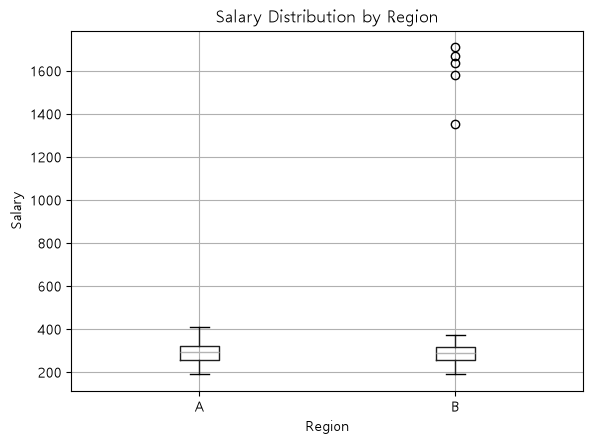

In [17]:
# 아래를 수행해 보세요:
print(df2.head(3))
print()
print("지역별 평균 연봉:")
print(df2.groupby('region')['salary'].mean())
print()
print("지역별 중앙값 연봉:")
print(df2.groupby('region')['salary'].median())

plt.figure(figsize=(10, 6))
df2.boxplot(column='salary', by='region')

plt.title('Salary Distribution by Region')
plt.suptitle('') 
plt.xlabel('Region')
plt.ylabel('Salary')
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

1. A 지역과 B 지역의 평균 연봉은 어떻게 다른가요?
   - 두 지역의 평균 차이가 의미하는 바는 무엇인가요?
   - 고소득자가 있는 지역의 평균은 어떤 영향을 받을까요?

2. 중앙값은 어떠한가요?
   - 평균과 비교했을 때, 중앙값이 더 낮거나 높다면 어떤 해석이 가능할까요?

3. 극단값(고소득자)의 영향은 어디에서 더 크게 나타날까요?
   - 평균과 중앙값 중 어떤 지표가 극단값에 더 민감한가요?

4. 박스플롯을 통해 어떤 점을 관찰할 수 있나요?
   - 이상치(Outlier)는 어떻게 표시되나요?
   - 두 지역의 분포 폭(사분위 범위)은 어떻게 다른가요?

5. 평균만 보고 판단했을 때 생길 수 있는 오해는 무엇인가요?
   - 어떤 경우에는 중앙값이 더 유용한 지표일 수 있을까요?

In [19]:
# 데이터를 어떻게 읽을까요?
mean_vals = df2.groupby('region')['salary'].mean()
median_vals = df2.groupby('region')['salary'].median()

diff = mean_vals - median_vals
print("[1번문제]")
print(f"A 지역과 B 지역의 평균 연봉을 비교해보면, A 지역은 {mean_vals['A']:.2f}, B 지역은 {mean_vals['B']:.2f}로 나타난다.")
print(f"두 지역의 평균 차이는 {abs(mean_vals['A'] - mean_vals['B']):.2f}로, B 지역에 고소득자가 포함되어 있어 평균이 실제 대다수 직원의 수준보다 높게 왜곡되었을 가능성이 있다.")
print()
print("[2번문제]")
print(f"중앙값을 보면 A 지역은 {median_vals['A']:.2f}, B 지역은 {median_vals['B']:.2f}이다.")
if diff['B'] > diff['A']:
    print("B 지역은 평균이 중앙값보다 더 크게 높아, 소수의 고소득자가 평균을 끌어올리는 오른쪽 꼬리 분포를 보인다고 해석할 수 있다.")
else:
    print("두 지역의 평균과 중앙값 차이가 비슷하다면, 분포의 비대칭 정도가 유사하다고 볼 수 있다.")
print()
print("[3번문제]")
print("평균은 모든 값을 합산해 계산하므로 극단값(고소득자)에 민감하게 반응하는 반면,")
print("중앙값은 순서상 가운데 값만 보기 때문에 극단값의 영향을 거의 받지 않는다.")
print("따라서 고소득자의 영향은 평균에서 뚜렷하게 나타나고, 중앙값에서는 거의 드러나지 않는다.")
print()
print("[4번문제]")
print("박스플롯에서는 사분위범위(IQR) 밖에 위치한 값들이 점으로 표시되어 이상치로 나타나며,")
print("B 지역 상단에 찍힌 점들이 바로 이 고소득자들에 해당한다.")
print("또한 B 지역의 박스(IQR) 폭이 A보다 넓다면, 지역 내 급여 격차가 더 크다는 것을 의미한다.")
print()
print("[5번문제]")
print("평균만 보고 판단하면 B 지역 직원들이 전반적으로 더 잘 번다고 오해할 수 있으나,")
print("실제로는 소수의 고소득자가 평균을 끌어올린 것일 수 있다.")
print("이런 비대칭 분포에서는 중앙값이 일반적인 직원의 실제 연봉 수준을 더 안정적으로 대표한다.")

[1번문제]
A 지역과 B 지역의 평균 연봉을 비교해보면, A 지역은 292.51, B 지역은 347.59로 나타난다.
두 지역의 평균 차이는 55.09로, B 지역에 고소득자가 포함되어 있어 평균이 실제 대다수 직원의 수준보다 높게 왜곡되었을 가능성이 있다.

[2번문제]
중앙값을 보면 A 지역은 294.32, B 지역은 287.35이다.
B 지역은 평균이 중앙값보다 더 크게 높아, 소수의 고소득자가 평균을 끌어올리는 오른쪽 꼬리 분포를 보인다고 해석할 수 있다.

[3번문제]
평균은 모든 값을 합산해 계산하므로 극단값(고소득자)에 민감하게 반응하는 반면,
중앙값은 순서상 가운데 값만 보기 때문에 극단값의 영향을 거의 받지 않는다.
따라서 고소득자의 영향은 평균에서 뚜렷하게 나타나고, 중앙값에서는 거의 드러나지 않는다.

[4번문제]
박스플롯에서는 사분위범위(IQR) 밖에 위치한 값들이 점으로 표시되어 이상치로 나타나며,
B 지역 상단에 찍힌 점들이 바로 이 고소득자들에 해당한다.
또한 B 지역의 박스(IQR) 폭이 A보다 넓다면, 지역 내 급여 격차가 더 크다는 것을 의미한다.

[5번문제]
평균만 보고 판단하면 B 지역 직원들이 전반적으로 더 잘 번다고 오해할 수 있으나,
실제로는 소수의 고소득자가 평균을 끌어올린 것일 수 있다.
이런 비대칭 분포에서는 중앙값이 일반적인 직원의 실제 연봉 수준을 더 안정적으로 대표한다.


# 문제 3. 이상값과 분산 비교

**📘 문제**

- 1반과 2반의 시험 점수 분포를 비교해 봅시다.
- 2반에는 극단적인 이상값(예: 부정행위로 0점)이 포함되어 있습니다.

In [21]:
# 데이터 생성
np.random.seed(2025)  # 재현 가능성을 위해 시드 고정

# 1반: 평균 75, 표준편차 8
class1 = np.random.normal(75, 8, 30)

# 2반: 일반 학생 + 이상값(0점, 130점)
class2 = np.concatenate([
    np.random.normal(75, 15, 28),  # 일반 학생
    [0, 130]                       # 극단적인 이상값
])

df3 = pd.DataFrame({
    'class': ['1반'] * 30 + ['2반'] * 30,
    'score': np.concatenate([class1, class2])
})
df3.head(4)

,class,score
0,1반,74.260879
1,1반,80.874285
2,1반,63.488944
3,1반,69.692624


**📌 아래를 수행해 보세요:**

1. 각 반의 평균, 표준편차, 최소/최대값을 계산해 봅시다.
2. 박스플롯을 사용하여 두 반의 분포 차이를 시각적으로 비교해 봅시다.
3. 이상값이 통계 지표에 어떤 영향을 주는지 생각해 봅시다.

            mean        std        min         max
class                                             
1반     75.724316   7.062710  60.685416   92.175893
2반     73.728848  22.340818   0.000000  130.000000


<Figure size 1000x600 with 0 Axes>

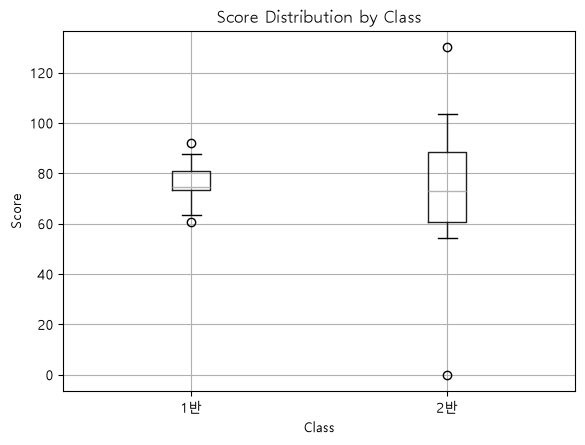

2반 - 이상값 포함: 73.72884842544566 22.34081810379384
2반 - 이상값 제외: 74.35233759869178 14.73341148573053


<Figure size 1000x600 with 0 Axes>

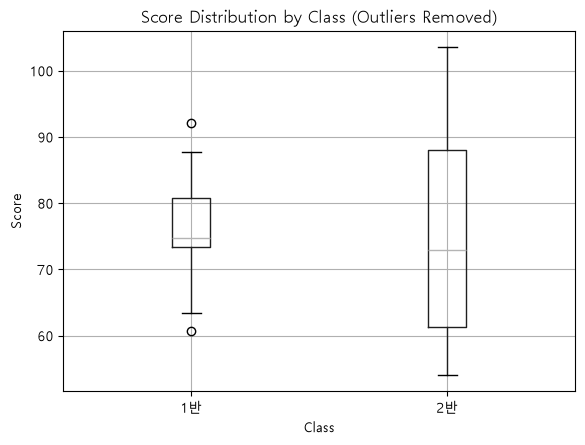

In [22]:
# 아래를 수행해 보세요:
# 1. 각 반의 평균, 표준편차, 최소/최대값
stats = df3.groupby('class')['score'].agg(['mean', 'std', 'min', 'max'])
print(stats)

# 2. 박스플롯으로 분포 비교
plt.figure(figsize=(10, 6))
df3.boxplot(column='score', by='class')
plt.title('Score Distribution by Class')
plt.suptitle('')
plt.xlabel('Class')
plt.ylabel('Score')
plt.show()

# 3. 이상값 제외했을 때와 비교 (2반에서 0점, 130점 제외)
class2_no_outlier = df3[(df3['class']=='2반') & (~df3['score'].isin([0, 130]))]['score']
print("2반 - 이상값 포함:", df3[df3['class']=='2반']['score'].mean(), df3[df3['class']=='2반']['score'].std())
print("2반 - 이상값 제외:", class2_no_outlier.mean(), class2_no_outlier.std())

# 이상값 제외한 데이터로 다시 df 구성
df3_clean = df3[~((df3['class']=='2반') & (df3['score'].isin([0, 130])))]

plt.figure(figsize=(10, 6))
df3_clean.boxplot(column='score', by='class')
plt.title('Score Distribution by Class (Outliers Removed)')
plt.suptitle('')
plt.xlabel('Class')
plt.ylabel('Score')
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

1. 어떤 반의 점수 분산이 더 크고, 왜 그럴까요?
   - 점수 분포의 퍼짐 정도는 어떤 지표로 확인할 수 있을까요?
   - 이상값이 포함되면 표준편차나 범위는 어떻게 달라질까요?

2. 이상값이 있는 반의 평균은 어떤 영향을 받았나요?
   - 극단적으로 낮거나 높은 점수가 평균을 끌어내리거나 끌어올렸나요?
   - 평균과 중앙값의 차이가 의미하는 바는 무엇인가요?

3. 박스플롯을 통해 이상값은 어떻게 드러나나요?
   - 이상값(outlier)은 박스플롯에서 어떤 형태로 나타나나요?
   - 두 반의 박스(사분위 범위)는 어떻게 다르게 보이나요?

4. 평균만 보고 평가했을 때 생길 수 있는 오해는 무엇인가요?
   - 예를 들어, 교사가 평균 점수만 보고 2반이 부족하다고 판단한다면?
   - 중앙값이나 표준편차 같은 지표와 함께 분석하는 것은 왜 중요할까요?

In [23]:
# 데이터를 어떻게 읽을까요?
stats = df3.groupby('class')['score'].agg(['mean', 'std', 'min', 'max'])
median_vals = df3.groupby('class')['score'].median()
print("[1번문제]")
print(f"1반의 표준편차는 {stats.loc['1반', 'std']:.2f}, 2반의 표준편차는 {stats.loc['2반', 'std']:.2f}로,")
print(f"2반의 점수 분산이 더 크게 나타난다. 이는 2반에 0점과 130점 같은 극단적인 이상값이 포함되어 있기 때문이다.")
print(f"점수 분포의 퍼짐 정도는 표준편차, 분산, 범위(최댓값-최솟값), 사분위범위(IQR) 등으로 확인할 수 있다.")
print(f"이상값이 포함되면 표준편차와 범위가 실제 대다수 학생의 점수 차이보다 훨씬 크게 부풀려진다.")
print()
print("[2번문제]")
print(f"2반의 평균은 {stats.loc['2반', 'mean']:.2f}, 중앙값은 {median_vals['2반']:.2f}이다.")
print(f"0점이라는 극단적으로 낮은 값과 130점이라는 극단적으로 높은 값이 서로 반대 방향으로 평균을 끌어당기지만,")
print(f"두 값이 완전히 상쇄되지 않는 이상 평균은 왜곡된다.")
print(f"평균과 중앙값의 차이가 크다면, 이는 소수의 극단값이 평균을 실제 중심 경향과 다르게 이동시켰다는 것을 의미한다.")
print()
print("[3번문제]")
print(f"박스플롯에서 이상값은 박스(사분위범위) 밖에 별도의 점으로 표시된다.")
print(f"2반의 박스플롯에는 아래쪽(0점 근처)과 위쪽(130점 근처)에 각각 점이 찍혀 극단값의 존재가 시각적으로 드러난다.")
print(f"1반의 박스는 상대적으로 좁고 대칭적인 반면, 2반의 박스는 더 넓거나 이상치로 인해 전체 범위가 크게 늘어난 모습을 보인다.")
print()
print("[4번문제]")
print(f"평균만 보고 2반을 평가하면, 실제로는 대다수 학생이 비슷한 수준인데도 극단값 때문에 평균이 왜곡되어")
print(f"'2반이 부족하다' 혹은 '2반이 우수하다'는 잘못된 결론을 내릴 수 있다.")
print(f"따라서 평균과 함께 중앙값, 표준편차, 박스플롯 같은 지표를 함께 봐야 이상값에 흔들리지 않는 정확한 해석이 가능하다.")

[1번문제]
1반의 표준편차는 7.06, 2반의 표준편차는 22.34로,
2반의 점수 분산이 더 크게 나타난다. 이는 2반에 0점과 130점 같은 극단적인 이상값이 포함되어 있기 때문이다.
점수 분포의 퍼짐 정도는 표준편차, 분산, 범위(최댓값-최솟값), 사분위범위(IQR) 등으로 확인할 수 있다.
이상값이 포함되면 표준편차와 범위가 실제 대다수 학생의 점수 차이보다 훨씬 크게 부풀려진다.

[2번문제]
2반의 평균은 73.73, 중앙값은 73.00이다.
0점이라는 극단적으로 낮은 값과 130점이라는 극단적으로 높은 값이 서로 반대 방향으로 평균을 끌어당기지만,
두 값이 완전히 상쇄되지 않는 이상 평균은 왜곡된다.
평균과 중앙값의 차이가 크다면, 이는 소수의 극단값이 평균을 실제 중심 경향과 다르게 이동시켰다는 것을 의미한다.

[3번문제]
박스플롯에서 이상값은 박스(사분위범위) 밖에 별도의 점으로 표시된다.
2반의 박스플롯에는 아래쪽(0점 근처)과 위쪽(130점 근처)에 각각 점이 찍혀 극단값의 존재가 시각적으로 드러난다.
1반의 박스는 상대적으로 좁고 대칭적인 반면, 2반의 박스는 더 넓거나 이상치로 인해 전체 범위가 크게 늘어난 모습을 보인다.

[4번문제]
평균만 보고 2반을 평가하면, 실제로는 대다수 학생이 비슷한 수준인데도 극단값 때문에 평균이 왜곡되어
'2반이 부족하다' 혹은 '2반이 우수하다'는 잘못된 결론을 내릴 수 있다.
따라서 평균과 함께 중앙값, 표준편차, 박스플롯 같은 지표를 함께 봐야 이상값에 흔들리지 않는 정확한 해석이 가능하다.


# 문제 4. IQR 이상값 제거

**📘 문제**

- 앞의 문제에서 2반에는 **극단적인 이상값(예: 매우 낮은 점수)**이 포함되어 있어
  통계 지표, 특히 평균에 큰 영향을 주는 것을 확인했습니다.
- 이번에는 **IQR(사분위 범위)**을 기준으로 이상값을 제거한 뒤, 이상값 제거 전후의 평균을 비교해 봅시다

<br>

**📌 아래를 수행해 보세요:**

- 2반의 점수 데이터를 대상으로 IQR 기준을 사용해 이상값을 판별하고 제거해 봅시다.
- 이상값 제거 전과 제거 후의 평균을 각각 계산해 봅시다.
- 이상값 제거가 평균에 어떤 영향을 주는지 설명해 봅시다.
- 필요하다면 중앙값과도 비교해 봅시다.

In [24]:
# 아래를 수행해 보세요:
# 2반 데이터 추출
class2_scores = df3[df3['class']=='2반']['score']

# IQR 기준 이상값 판별
Q1 = class2_scores.quantile(0.25)
Q3 = class2_scores.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상값 제거
class2_filtered = class2_scores[(class2_scores >= lower_bound) & (class2_scores <= upper_bound)]
outliers = class2_scores[(class2_scores < lower_bound) | (class2_scores > upper_bound)]

# 평균/중앙값 비교
mean_before = class2_scores.mean()
mean_after = class2_filtered.mean()
median_before = class2_scores.median()
median_after = class2_filtered.median()

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"이상값 판별 범위: {lower_bound:.2f} ~ {upper_bound:.2f}")
print(f"이상값: {outliers.tolist()}")
print()
print(f"제거 전 평균: {mean_before:.2f}, 제거 후 평균: {mean_after:.2f}")
print(f"제거 전 중앙값: {median_before:.2f}, 제거 후 중앙값: {median_after:.2f}")

Q1: 60.75, Q3: 88.37, IQR: 27.61
이상값 판별 범위: 19.33 ~ 129.79
이상값: [0.0, 130.0]

제거 전 평균: 73.73, 제거 후 평균: 74.35
제거 전 중앙값: 73.00, 제거 후 중앙값: 73.00


**🧠 데이터를 어떻게 읽을까요?**

1. 이상값 제거 전후 평균은 어떻게 달라졌나요?
   - 평균이 중앙값에 가까워졌나요?
   - 이상값 제거가 평균에 어떤 방향으로 영향을 주었나요?

2. 왜 IQR을 기준으로 이상값을 판단할까요?
   - IQR은 데이터를 어떻게 나누고, 어떤 방식으로 이상값을 정의하나요?
   - 평균이나 표준편차 기준과 비교했을 때 어떤 점이 더 강건할까요?

3. 이상값은 언제 제거하고, 언제 유지해야 할까요?
   - 분석 목적에 따라 이상값은 중요한 정보가 될 수 있습니다.

4. 중앙값과 평균은 각각 어떤 상황에서 더 유용한 지표인가요?
   - 이상값이 있을 때 어떤 지표가 더 신뢰할 수 있나요?
   - 두 지표를 함께 보면 어떤 장점이 있을까요?

In [27]:
# 데이터를 어떻게 읽을까요?
print("[1번문제]")
print(f"이상값 제거 전 평균은 {mean_before:.2f}, 제거 후 평균은 {mean_after:.2f}이다.")
print(f"제거 후 평균이 중앙값({median_after:.2f})에 더 멀어졌음을 보여주며,")
print(f"이는 0점과 130점이라는 두 극단값이 서로 반대 방향으로 평균을 당기고 있었고, 그 힘이 완전히 대칭적이지 않았기 때문으로 보인다.")
print(f"이는 이상값 제거가 항상 평균을 중앙값에 가깝게 만드는 것은 아니라는 점을 보여준다.")
print()
print("[2번문제]")
print("IQR은 데이터를 정렬한 뒤 하위 25%(Q1)와 상위 25%(Q3) 지점을 기준으로,")
print("그 사이 구간(사분위범위)에서 벗어난 값을 이상값으로 정의하는 방식이다.")
print("구체적으로는 Q1 - 1.5*IQR 미만이거나 Q3 + 1.5*IQR 초과인 값을 이상값으로 판단한다.")
print("평균이나 표준편차는 그 자체가 이상값의 영향을 받아 값이 커지므로 기준이 흔들리지만,")
print("IQR은 중간 50% 데이터만 사용하기 때문에 극단값에 영향을 받지 않아 좀 더 정확한 기준이 된다.")
print()
print("[3번문제]")
print("이상값은 데이터 입력 오류나 측정 오류처럼 신뢰할 수 없는 값일 때는 제거하는 것이 적절하다.")
print("하지만 실제로 존재하는 극단적인 사례(예: 최우수 학생, 특수 상황)를 반영한 값이라면,")
print("분석 목적에 따라 오히려 중요한 정보일 수 있으므로 함부로 제거하지 않고 유지하거나 별도로 분석해야 한다.")
print()
print("[4번문제]")
print("평균은 데이터가 대칭적이고 이상값이 없을 때 전체를 잘 대표하는 지표이다.")
print("반면 중앙값은 이상값이나 비대칭 분포가 있을 때 더 신뢰할 수 있는 지표로,")
print("극단값의 영향을 받지 않고 '일반적인 값'을 안정적으로 보여준다.")
print("평균과 중앙값을 함께 보면 두 값의 차이를 통해 분포가 어느 정도 치우쳐 있는지,")
print("이상값의 영향이 얼마나 큰지를 함께 파악할 수 있다는 장점이 있다.")

[1번문제]
이상값 제거 전 평균은 73.73, 제거 후 평균은 74.35이다.
제거 후 평균이 중앙값(73.00)에 더 멀어졌음을 보여주며,
이는 0점과 130점이라는 두 극단값이 서로 반대 방향으로 평균을 당기고 있었고, 그 힘이 완전히 대칭적이지 않았기 때문으로 보인다.
이는 이상값 제거가 항상 평균을 중앙값에 가깝게 만드는 것은 아니라는 점을 보여준다.

[2번문제]
IQR은 데이터를 정렬한 뒤 하위 25%(Q1)와 상위 25%(Q3) 지점을 기준으로,
그 사이 구간(사분위범위)에서 벗어난 값을 이상값으로 정의하는 방식이다.
구체적으로는 Q1 - 1.5*IQR 미만이거나 Q3 + 1.5*IQR 초과인 값을 이상값으로 판단한다.
평균이나 표준편차는 그 자체가 이상값의 영향을 받아 값이 커지므로 기준이 흔들리지만,
IQR은 중간 50% 데이터만 사용하기 때문에 극단값에 영향을 받지 않아 좀 더 정확한 기준이 된다.

[3번문제]
이상값은 데이터 입력 오류나 측정 오류처럼 신뢰할 수 없는 값일 때는 제거하는 것이 적절하다.
하지만 실제로 존재하는 극단적인 사례(예: 최우수 학생, 특수 상황)를 반영한 값이라면,
분석 목적에 따라 오히려 중요한 정보일 수 있으므로 함부로 제거하지 않고 유지하거나 별도로 분석해야 한다.

[4번문제]
평균은 데이터가 대칭적이고 이상값이 없을 때 전체를 잘 대표하는 지표이다.
반면 중앙값은 이상값이나 비대칭 분포가 있을 때 더 신뢰할 수 있는 지표로,
극단값의 영향을 받지 않고 '일반적인 값'을 안정적으로 보여준다.
평균과 중앙값을 함께 보면 두 값의 차이를 통해 분포가 어느 정도 치우쳐 있는지,
이상값의 영향이 얼마나 큰지를 함께 파악할 수 있다는 장점이 있다.


# 문제 5. 변수 유형 분류

**📘 문제**

- 아래 데이터에서 변수의 유형(연속형, 범주형, 이산형 등)을 구분해 봅시다.
- 변수의 의미를 고려하여 어떤 분석 방식이 적절한지도 함께 생각해 봅시다.

In [29]:
# 데이터 생성
np.random.seed(2025)
df5 = pd.DataFrame({
    'age': np.random.randint(18, 65, 200),
    'coffee_type': np.random.choice(['아메리카노', '라떼', '카페모카'], 200),
    'size': np.random.choice(['Small', 'Medium', 'Large'], 200),
    'price': np.random.normal(4500, 500, 200),
    'satisfaction': np.random.randint(1, 6, 200)
})
df5.head(10)

,age,coffee_type,size,price,satisfaction
0,48,카페모카,Small,4435.448359,1
1,36,라떼,Small,4849.195869,4
2,48,카페모카,Large,4365.135391,1
3,30,아메리카노,Medium,3979.605848,2
4,21,카페모카,Small,4650.242695,1
5,37,카페모카,Large,4697.757283,3
6,30,아메리카노,Large,4334.108515,1
7,50,라떼,Medium,4500.113402,5
8,40,라떼,Small,4100.648031,5
9,55,아메리카노,Medium,4613.995414,4


**📌 아래를 수행해 보세요:**

1. 각 변수의 데이터 타입을 확인해 봅시다.

2. 변수의 의미를 기준으로 다음 중 어떤 유형에 해당하는지 분류해 봅시다.
   - 연속형 (numeric-continuous)
   - 이산형 (numeric-discrete)
   - 범주형 (categorical)
   - 서열형 범주 (ordinal-categorical)

In [33]:
# 아래를 수행해 보세요:
print("=== df5 ===")
print(df5.dtypes)
print()

print("--- 변수 유형 분류 ---")
print('age, price: 연속형 \ncoffee_type, size: 범주형 \nsatisfaction: 서열형 범주')

=== df5 ===
age               int32
coffee_type         str
size                str
price           float64
satisfaction      int32
dtype: object

--- 변수 유형 분류 ---
age, price: 연속형 
coffee_type, size: 범주형 
satisfaction: 서열형 범주


**🧠 데이터를 어떻게 읽을까요?**

1. 숫자처럼 보이지만 사실은 범주형 또는 서열형으로 해석하는 변수가 있다면 무엇일까요?

2. 변수 유형에 따라 적절한 분석 방법이나 시각화 방식은 어떻게 달라질까요?

In [35]:
# 데이터를 어떻게 읽을까요?
print("[1번문제]")
print("만족도나 설문 조사에서 [매우만족-만족-보통-불만족-매우불만족] 같은 범주형 값들에 숫자(정수)를 부여하는 경우에는 범주형/서열형으로 해석해야한다.")
print()

print("[2번문제]")
print("연속형(numeric-continuous): 평균, 표준편차, 히스토그램, 박스플롯, 산점도 등으로 분포와 중심경향을 분석한다.")
print("이산형(numeric-discrete): 평균은 가능하지만 값이 정수 단위로 제한되어 막대그래프나 카운트플롯이 더 적합할 때가 많다.")
print("범주형(categorical): 평균/표준편차는 의미가 없고, 빈도수(value_counts), 막대그래프, 파이차트로 분포를 확인한다.")
print("서열형 범주(ordinal-categorical): 순서 정보가 있으므로 순서를 유지한 막대그래프나 순위 기반 통계(중앙값, 순위상관 등)를 활용한다.")

[1번문제]
만족도나 설문 조사에서 [매우만족-만족-보통-불만족-매우불만족] 같은 범주형 값들에 숫자(정수)를 부여하는 경우에는 범주형/서열형으로 해석해야한다.

[2번문제]
연속형(numeric-continuous): 평균, 표준편차, 히스토그램, 박스플롯, 산점도 등으로 분포와 중심경향을 분석한다.
이산형(numeric-discrete): 평균은 가능하지만 값이 정수 단위로 제한되어 막대그래프나 카운트플롯이 더 적합할 때가 많다.
범주형(categorical): 평균/표준편차는 의미가 없고, 빈도수(value_counts), 막대그래프, 파이차트로 분포를 확인한다.
서열형 범주(ordinal-categorical): 순서 정보가 있으므로 순서를 유지한 막대그래프나 순위 기반 통계(중앙값, 순위상관 등)를 활용한다.


# 문제 6. 상관관계 분석

**📘 문제**

- 이번에는 변수들 간의 **관계(상관관계)**를 분석해 봅시다.
- 특히 기온(`temp`), 습도(`humidity`), 판매(`sales`) 변수 간의 관계를 수치와 시각화로 살펴보겠습니다.

In [37]:
# 데이터 생성
np.random.seed(202)

temp = np.random.normal(25, 5, 100)
humidity = np.random.normal(60, 10, 100)
sales = temp * 10 - humidity * 2 + np.random.normal(0, 20, 100) + 200

df6 = pd.DataFrame({'temp': temp, 'humidity': humidity, 'sales': sales})
df6.head(10)

,temp,humidity,sales
0,21.320631,46.569804,332.531641
1,20.699234,62.568414,296.394337
2,20.383588,53.850603,286.911904
3,26.192266,61.817864,321.817952
4,22.083919,51.493228,280.362673
5,28.371628,48.938293,373.287935
6,25.118502,59.732944,334.021025
7,26.105594,54.860953,353.317443
8,20.800053,48.029565,328.277704
9,24.377323,68.506515,302.135401


**📌 아래를 수행해 보세요:**

1. 아래의 기온, 습도, 매출 데이터를 사용하여 상관계수 행렬을 출력해 봅시다.

2. 페어플롯(pairplot)을 이용하여 변수 간의 관계를 시각화해 봅시다.

              temp  humidity     sales
temp      1.000000 -0.115936  0.906593
humidity -0.115936  1.000000 -0.390105
sales     0.906593 -0.390105  1.000000


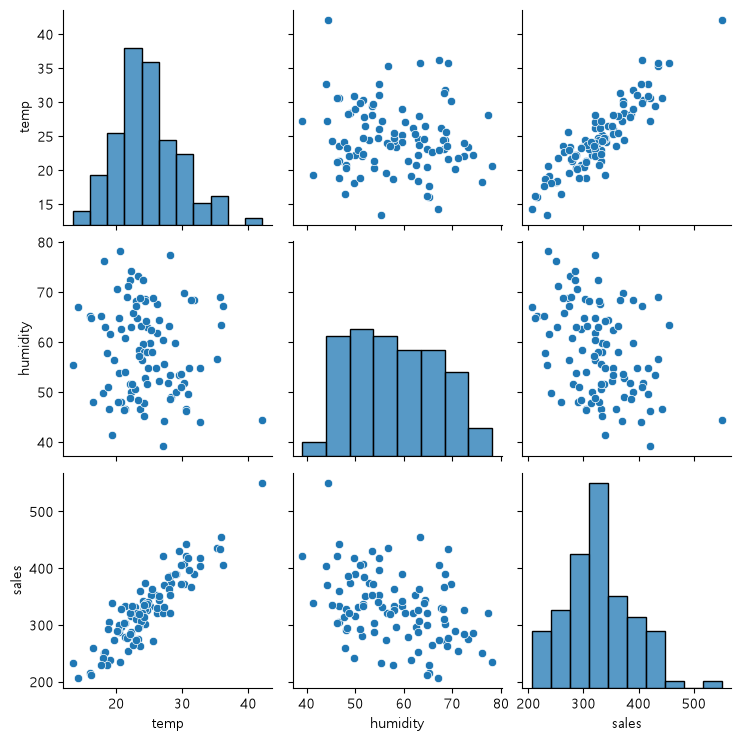

In [38]:
# 아래를 수행해 보세요:
import seaborn as sns

# 상관계수 행렬
corr_matrix = df6.corr()
print(corr_matrix)

# 페어플롯
sns.pairplot(df6)
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

1. 출력된 상관계수 행렬을 보고,
   - 어떤 변수와 `sales` 간의 상관계수가 가장 높은가요?
   - 어느 쌍이 **양의 상관관계**, 어느 쌍이 **음의 상관관계**인가요?

2. 페어플롯에서
   - 어떤 변수 쌍은 **직선 형태**로 관계가 보이나요?
   - 어떤 변수 쌍은 **분산이 크거나 패턴이 없는**가요?

3. **상관관계가 반드시 인과관계를 의미하지는 않습니다.**
   - 온도와 매출에 상관관계가 있다고 해서, 온도가 매출을 직접적으로 증가시킨다고 볼 수 있을까요?

4. 이 데이터를 바탕으로 어떤 **추가 가설**이나 **실험 설계**를 생각해볼 수 있을까요?

In [39]:
# 데이터를 어떻게 읽을까요?
print("[1번문제]")
print(f"sales와 상관계수가 가장 높은 변수는 temp로, 상관계수는 {corr_matrix.loc['temp','sales']:.2f}이다.")
print(f"temp와 sales는 양의 상관관계({corr_matrix.loc['temp','sales']:.2f})를 보이고,")
print(f"humidity와 sales는 음의 상관관계({corr_matrix.loc['humidity','sales']:.2f})를 보인다.")
print(f"temp와 humidity 사이는 약한 음의 상관관계({corr_matrix.loc['temp','humidity']:.2f})로 거의 관련이 없다고 볼 수 있다.")
print()
print("[2번문제]")
print("페어플롯에서 temp와 sales는 뚜렷한 직선(우상향) 형태로 강한 양의 관계가 보인다.")
print("humidity와 sales는 완만한 우하향 패턴을 보이지만 산점도가 넓게 퍼져있어 temp-sales보다 관계가 약하다.")
print("temp와 humidity는 뚜렷한 패턴 없이 점들이 흩어져 있어 거의 무관하다고 봐야할 것 같다.")
print()
print("[3번문제]")
print("상관관계는 두 변수가 함께 움직이는 정도만 보여줄 뿐, 한쪽이 다른 쪽의 원인이라는 것을 증명하지는 않는다.")
print("온도와 매출이 상관관계를 보인다고 해서 온도가 매출을 직접 증가시킨다고 단정할 수 없으며,")
print("계절이나 날씨로 인한 소비 패턴 변화 같은 제3의 요인이 두 변수 모두에 영향을 미쳤을 가능성도 배재하면 안된다.")
print()
print("[4번문제]")
print("추가 가설로는 다음과 같은 것을 생각해볼 수 있다.")
print("- 계절, 요일, 프로모션 여부 같은 제3의 변수를 추가해 다중회귀분석으로 실제 영향력을 분리해서 확인")
print("- 실험적으로 동일 조건에서 온도만 다르게 설정한 대조군 데이터를 수집해 인과관계를 검증")

[1번문제]
sales와 상관계수가 가장 높은 변수는 temp로, 상관계수는 0.91이다.
temp와 sales는 양의 상관관계(0.91)를 보이고,
humidity와 sales는 음의 상관관계(-0.39)를 보인다.
temp와 humidity 사이는 약한 음의 상관관계(-0.12)로 거의 관련이 없다고 볼 수 있다.

[2번문제]
페어플롯에서 temp와 sales는 뚜렷한 직선(우상향) 형태로 강한 양의 관계가 보인다.
humidity와 sales는 완만한 우하향 패턴을 보이지만 산점도가 넓게 퍼져있어 temp-sales보다 관계가 약하다.
temp와 humidity는 뚜렷한 패턴 없이 점들이 흩어져 있어 거의 무관하다고 봐야할 것 같다.

[3번문제]
상관관계는 두 변수가 함께 움직이는 정도만 보여줄 뿐, 한쪽이 다른 쪽의 원인이라는 것을 증명하지는 않는다.
온도와 매출이 상관관계를 보인다고 해서 온도가 매출을 직접 증가시킨다고 단정할 수 없으며,
계절이나 날씨로 인한 소비 패턴 변화 같은 제3의 요인이 두 변수 모두에 영향을 미쳤을 가능성도 배재하면 안된다.

[4번문제]
추가 가설로는 다음과 같은 것을 생각해볼 수 있다.
- 계절, 요일, 프로모션 여부 같은 제3의 변수를 추가해 다중회귀분석으로 실제 영향력을 분리해서 확인
- 실험적으로 동일 조건에서 온도만 다르게 설정한 대조군 데이터를 수집해 인과관계를 검증


# 문제 7. 범주형 변수 시각화

**📘 문제**

- 앞에서는 수치형 변수의 분포를 시각화하고, 변수 간의 관계도 살펴보았습니다.
- 이번에는 범주형 변수인 커피 음료 데이터를 시각화해 봅시다.
- 어떤 종류가 많이 판매되었는지 빈도 분석을 통해 알아보겠습니다.

In [5]:
# 데이터 생성
df7 = pd.DataFrame({
    'drink': np.random.choice(['아메리카노', '라떼', '콜드브루'], 300)
})
df7.head(10)

,drink
0,아메리카노
1,아메리카노
2,아메리카노
3,아메리카노
4,라떼
5,라떼
6,콜드브루
7,콜드브루
8,콜드브루
9,아메리카노


**📌 아래를 수행해 보세요:**

1. 아래 데이터에서 drink 변수는 판매된 음료의 종류를 나타냅니다.
   - 각각 몇 개씩 판매되었는지 빈도표를 만들어 확인해 봅시다.
   - **막대그래프(bar plot)**를 그려서 결과를 시각화해 봅시다.

2. 시각화 결과를 보고,
   - 어떤 음료가 가장 많이 팔렸는지 파악해 봅시다.
   - 이 결과를 마케팅 전략에 어떻게 활용할 수 있을지 생각해 봅시다.

drink
아메리카노    103
콜드브루     100
라떼        97
Name: count, dtype: int64


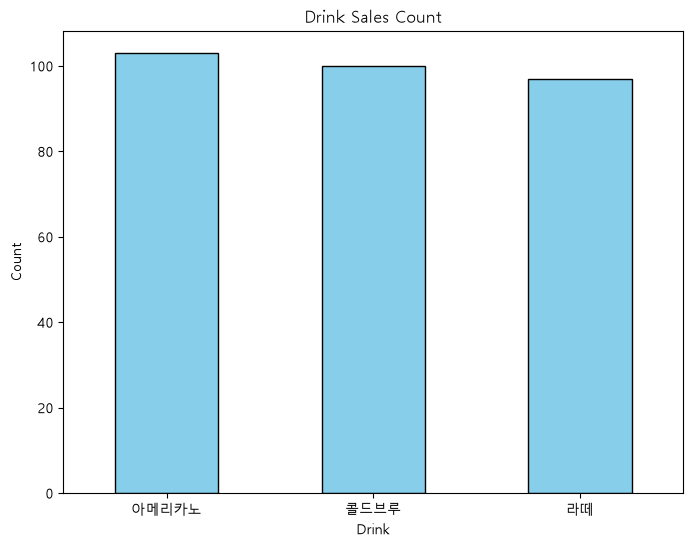

In [6]:
# 아래를 수행해 보세요:
# 빈도표
drink_counts = df7['drink'].value_counts()
print(drink_counts)

# 막대그래프
plt.figure(figsize=(8, 6))
drink_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Drink Sales Count')
plt.xlabel('Drink')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

1. 출력된 빈도표와 막대그래프를 보면, 어떤 음료가 가장 많이 판매되었나요?
   - 판매량이 가장 많은 음료는?
   - 그 다음으로 인기 있는 음료는?

2. 이 결과는 어떤 마케팅 전략에 활용할 수 있을까요?
   - 가장 많이 팔린 음료를 주력 상품으로 홍보해야 할까요?
   - 판매량이 적은 음료를 프로모션 대상으로 삼는 것은 어떨까요?

3. 막대그래프는 왜 범주형 변수에 적합할까요?
   - `drink`처럼 종류가 명확히 나뉘는 변수를 분석할 때 어떤 점이 중요한가요?

4. 범주형 변수 분석 시 주의할 점은?

In [7]:
# 데이터를 어떻게 읽을까요?
#
counts = df7['drink'].value_counts()
print("[1번문제]")
print(f"가장 많이 판매된 음료는 {counts.index[0]}로 {counts.iloc[0]}잔이 팔렸다.")
print(f"그 다음으로는 {counts.index[1]}({counts.iloc[1]}잔), {counts.index[2]}({counts.iloc[2]}잔) 순으로 인기가 있었다.")
print(f"세 음료 간 판매량 차이는 {counts.iloc[0] - counts.iloc[1]}, {counts.iloc[1] - counts.iloc[2]}잔 정도로 크지 않아, 특정 음료에 편중되기보다는 비교적 고르게 팔렸다고 볼 수 있다.")
print()
print("[2번문제]")
print(f"{counts.index[0]}가 가장 많이 팔렸으므로 주력 상품으로 삼아 재고를 충분히 확보하고 시즌 프로모션의 메인 메뉴로 홍보할 수 있다.")
print(f"반면 판매량이 가장 적은 {counts.index[-1]}은 할인 쿠폰이나 세트 구성(묶음 판매) 등으로 판매를 유도하는 전략을 고려해볼 수 있다.")
print("다만 차이가 크지 않으므로, 무리하게 한 음료에 집중하기보다는 세 음료 모두 고르게 홍보하는 전략도 유효할 수 있다.")
print()
print("[3번문제]")
print("막대그래프는 각 범주(음료 종류)가 서로 겹치지 않고 명확히 구분되기 때문에, 순서에 의미가 없는 범주형 변수에 적합하다.")
print("막대의 높이만으로 각 범주의 빈도(개수)를 직관적으로 비교할 수 있다는 점이 장점이고,")
print("특히 범주 간 순서가 없는 경우, 막대 순서를 임의로 바꿔도 해석에 문제가 없다는 점도 특징이다.")
print()
print("[4번문제]")
print("범주형 변수를 분석할 때는 평균이나 표준편차 같은 산술 통계를 적용하는 것은 의미가 없다는 점을주의해야 한다.")
print("또한 표본 크기가 작을 경우 특정 범주의 비율이 우연히 치우쳐 보일 수 있으므로, 표본 수와 비율도 함께 확인할 필요가 있다.")

[1번문제]
가장 많이 판매된 음료는 아메리카노로 103잔이 팔렸다.
그 다음으로는 콜드브루(100잔), 라떼(97잔) 순으로 인기가 있었다.
세 음료 간 판매량 차이는 3, 3잔 정도로 크지 않아, 특정 음료에 편중되기보다는 비교적 고르게 팔렸다고 볼 수 있다.

[2번문제]
아메리카노가 가장 많이 팔렸으므로 주력 상품으로 삼아 재고를 충분히 확보하고 시즌 프로모션의 메인 메뉴로 홍보할 수 있다.
반면 판매량이 가장 적은 라떼은 할인 쿠폰이나 세트 구성(묶음 판매) 등으로 판매를 유도하는 전략을 고려해볼 수 있다.
다만 차이가 크지 않으므로, 무리하게 한 음료에 집중하기보다는 세 음료 모두 고르게 홍보하는 전략도 유효할 수 있다.

[3번문제]
막대그래프는 각 범주(음료 종류)가 서로 겹치지 않고 명확히 구분되기 때문에, 순서에 의미가 없는 범주형 변수에 적합하다.
막대의 높이만으로 각 범주의 빈도(개수)를 직관적으로 비교할 수 있다는 점이 장점이고,
특히 범주 간 순서가 없는 경우, 막대 순서를 임의로 바꿔도 해석에 문제가 없다는 점도 특징이다.

[4번문제]
범주형 변수를 분석할 때는 평균이나 표준편차 같은 산술 통계를 적용하는 것은 의미가 없다는 점을주의해야 한다.
또한 표본 크기가 작을 경우 특정 범주의 비율이 우연히 치우쳐 보일 수 있으므로, 표본 수와 비율도 함께 확인할 필요가 있다.


# 문제 8. 요일별 평균 비교

**📘 문제**

- 이번에는 요일 별 소비 금액 데이터를 분석해 봅시다.
- 각 요일마다 평균 소비 금액이 얼마나 되는지 비교하고,
  **평일과 주말의 소비 패턴 차이**도 함께 살펴보겠습니다.

In [9]:
# 데이터 생성
df8 = pd.DataFrame({
    'day': np.random.choice(['월', '화', '수', '목', '금', '토', '일'], 500),
    'amount': np.random.normal(12000, 2000, 500)
})
df8.head(10)

,day,amount
0,일,11929.762254
1,화,12441.364086
2,월,10296.410722
3,수,15186.278824
4,토,11270.939258
5,월,7710.911458
6,수,12026.379738
7,토,9632.678471
8,화,12533.368409
9,수,11593.984937


**📌 아래를 수행해 보세요:**

1. 아래 데이터를 사용하여 `day`(요일)별 `amount`(소비 금액)의 평균을 계산해 봅시다.
2. 요일별 평균 금액을 **막대그래프(bar plot)**로 시각화해 봅시다.

day
월    11844.190528
화    12208.358866
수    11895.339319
목    12819.066336
금    11826.261714
토    12195.231948
일    11813.185696
Name: amount, dtype: float64


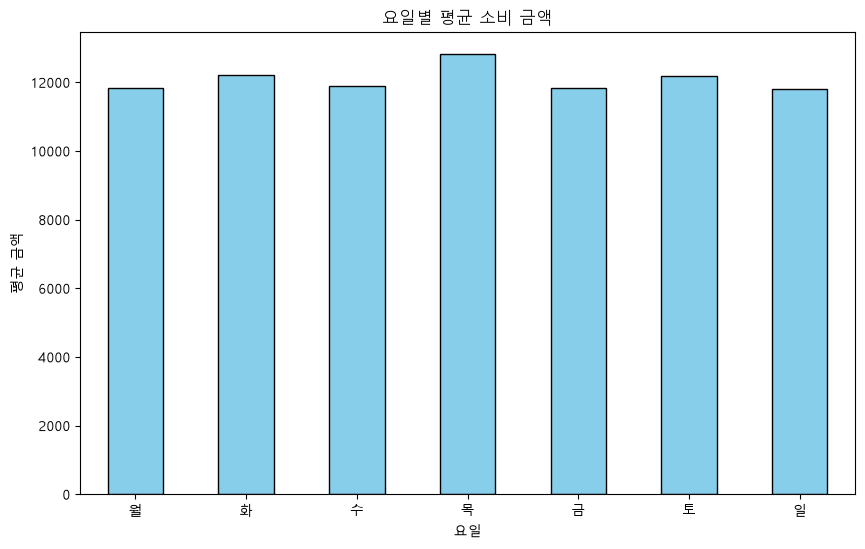

In [10]:
# 요일별 평균 금액
day_order = ['월', '화', '수', '목', '금', '토', '일']
day_avg = df8.groupby('day')['amount'].mean().reindex(day_order)
print(day_avg)

# 막대그래프
plt.figure(figsize=(10, 6))
day_avg.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('요일별 평균 소비 금액')
plt.xlabel('요일')
plt.ylabel('평균 금액')
plt.xticks(rotation=0)
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

1. 어떤 요일에 소비 금액이 가장 높나요?
   - 주말(토, 일)과 평일(월~금) 중 어떤 쪽의 평균이 더 높은가요?

2. 소비 금액이 적은 요일은 언제인가요? 왜 그럴까요?

3. 이 결과를 어떻게 활용할 수 있을까요?
   - 주말에 더 많은 재고를 준비하거나
   - 평일에 할인 이벤트를 기획하는 등의 운영/마케팅 전략으로 이어질 수 있을까요?

---

> 💬 정리해 보기
>
> - 범주형 변수(요일)별로 연속형 변수(소비 금액)의 평균을 비교하면 소비 패턴을 이해하고 전략을 수립하는 데 유용한 인사이트를 얻을 수 있습니다.

In [13]:
# 데이터를 어떻게 읽을까요?
day_avg = df8.groupby('day')['amount'].mean().reindex(day_order)
weekday_avg = day_avg[['월','화','수','목','금']].mean()
weekend_avg = day_avg[['토','일']].mean()

max_day = day_avg.idxmax()
min_day = day_avg.idxmin()

print("[1번문제]")
print(f"평균 소비 금액이 가장 높은 요일은 {max_day}요일으로 {day_avg[max_day]:.0f}원이다.")
print(f"주말(토,일) 평균은 {weekend_avg:.0f}원, 평일(월~금) 평균은 {weekday_avg:.0f}원으로,")
if weekend_avg > weekday_avg:
    print("주말 소비 금액이 평일보다 더 높게 나타났다.")
else:
    print("평일 소비 금액이 주말보다 더 높거나 비슷하게 나타난다.")
print()
print("[2번문제]")
print(f"평균 소비 금액이 가장 낮은 요일은 {min_day}요일으로 {day_avg[min_day]:.0f}원이다.")
print("아마,, 다음날이 평일의 시작이다 보니 돈을 소비할 시간이 크지 않았어서 낮게 나온 거라고 생각해봤다.")
print("그치만 사실 이 데이터는 요일과 금액이 서로 독립적으로 무작위 생성되었기 때문에,")
print("요일 간 차이는 실제 소비 패턴이 아니라 표본 추출 과정에서 생긴 우연한 변동일 가능성이 크다.")
print()
print("[3번문제]")
print("만약 실제 데이터에서 이런 차이가 통계적으로 유의미하다면,")
print("소비가 높은 요일에는 재고를 더 확보하고 인력을 추가 배치하고,")
print("소비가 낮은 요일에는 할인 이벤트나 프로모션으로 수요를 끌어올리는 전략을 고려할 수 있다.")
print("그리고 실제 적용 전에는 t-검정이나 분산분석(ANOVA) 등으로 요일 간 차이가 우연인지 실제 패턴인지 검증이 필요할 것이다.")
print("지금 이 데이터로 봤을 때에는 주말에 발주를 넣었던 양을 줄이고, 이를 목요일에 추가할 필요가 있을 것 같다. ")

[1번문제]
평균 소비 금액이 가장 높은 요일은 목요일으로 12819원이다.
주말(토,일) 평균은 12004원, 평일(월~금) 평균은 12119원으로,
평일 소비 금액이 주말보다 더 높거나 비슷하게 나타난다.

[2번문제]
평균 소비 금액이 가장 낮은 요일은 일요일으로 11813원이다.
아마,, 다음날이 평일의 시작이다 보니 돈을 소비할 시간이 크지 않았어서 낮게 나온 거라고 생각해봤다.
그치만 사실 이 데이터는 요일과 금액이 서로 독립적으로 무작위 생성되었기 때문에,
요일 간 차이는 실제 소비 패턴이 아니라 표본 추출 과정에서 생긴 우연한 변동일 가능성이 크다.

[3번문제]
만약 실제 데이터에서 이런 차이가 통계적으로 유의미하다면,
소비가 높은 요일에는 재고를 더 확보하고 인력을 추가 배치하고,
소비가 낮은 요일에는 할인 이벤트나 프로모션으로 수요를 끌어올리는 전략을 고려할 수 있다.
그리고 실제 적용 전에는 t-검정이나 분산분석(ANOVA) 등으로 요일 간 차이가 우연인지 실제 패턴인지 검증이 필요할 것이다.
지금 이 데이터로 봤을 때에는 주말에 발주를 넣었던 양을 줄이고, 이를 목요일에 추가할 필요가 있을 것 같다. 


# 문제 9. 정규분포와 표준편차

**📘 문제**

- 정규분포와 표준편차의 개념을 실제 데이터에 적용해 보겠습니다.
- 정규분포를 따르는 점수 데이터에서 다음을 확인해 봅시다:
  - 평균 ±1σ, 평균 ±2σ 범위에 속한 값들의 비율은 실제로 얼마나 되는가?
  - 이 결과가 이론적인 68-95-99 법칙과 얼마나 유사한지 비교해 봅시다.

<br>

**📌 아래를 수행해 보세요:**

1. 평균이 70, 표준편차가 10인 정규분포 데이터를 1000개 생성해 봅시다.
2. 평균을 중심으로 ±1σ, ±2σ 범위에 포함되는 데이터의 비율을 계산해 봅시다.
3. 결과를 바탕으로 68-95-99 법칙과 비교해 봅시다.

In [14]:
# 아래를 수행해 보세요:
np.random.seed(42)

# 1. 데이터 생성
scores = np.random.normal(70, 10, 1000)
mean_val = scores.mean()
std_val = scores.std()

# 2. ±1σ, ±2σ 범위 비율 계산
within_1sigma = ((scores >= mean_val - std_val) & (scores <= mean_val + std_val)).mean() * 100
within_2sigma = ((scores >= mean_val - 2*std_val) & (scores <= mean_val + 2*std_val)).mean() * 100

print(f"평균: {mean_val:.2f}, 표준편차: {std_val:.2f}")
print(f"±1σ 범위 내 데이터 비율: {within_1sigma:.2f}%  (이론값: 68%)")
print(f"±2σ 범위 내 데이터 비율: {within_2sigma:.2f}%  (이론값: 95%)")

평균: 70.19, 표준편차: 9.79
±1σ 범위 내 데이터 비율: 68.60%  (이론값: 68%)
±2σ 범위 내 데이터 비율: 95.60%  (이론값: 95%)


**🧠 데이터를 어떻게 읽을까요?**

1. ±1σ, ±2σ 범위에 실제로 몇 %의 데이터가 포함되었나요?
2. 이 결과는 68–95–99 법칙과 얼마나 비슷했나요?
3. 표준편차는 왜 중요한 지표인가요?
4. 이 개념이 실제로 어떻게 활용될 수 있을까요?

In [16]:
# 데이터를 어떻게 읽을까요?
diff_1sigma = abs(within_1sigma - 68)
diff_2sigma = abs(within_2sigma - 95)

print("[1번문제]")
print(f"±1σ 범위에는 실제로 {within_1sigma:.2f}%의 데이터가 포함되었고, ±2σ 범위에는 {within_2sigma:.2f}%가 포함되었다.")
print()
print("[2번문제]")
print(f"이론적인 68-95 법칙과 비교하면, ±1σ는 이론값(68%)과 {diff_1sigma:.2f}%p 차이가 나고,")
print(f"±2σ는 이론값(95%)과 {diff_2sigma:.2f}%p 차이가 난다.")
print("1000개의 표본으로도 이론적 비율과 매우 근접한 결과가 나온 것으로 보아,")
print("이 데이터가 정규분포를 잘 따르고 있음을 확인할 수 있었다.")
print()
print("[3번문제]")
print("표준편차는 데이터가 평균을 중심으로 얼마나 퍼져있는지를 나타내는 지표로,")
print("단순히 평균만으로는 알 수 없는 데이터의 변동성과 일관성을 파악할 수 있게 해준다.")
print("표준편차가 작으면 값들이 평균 근처에 밀집해 있고, 크면 값들이 넓게 흩어져 있다는 것을 의미한다.")
print()
print("[4번문제]")
print("이 개념은 실제로 품질관리(제조업에서 규격 이탈 제품 비율 추정),")
print("이상치 탐지(평균에서 몇 σ 이상 벗어난 값을 이상값으로 판단),")
print("성적 평가(상대평가에서 표준점수 산출), 금융(수익률의 변동성 리스크 측정) 등")
print("다양한 분야에서 '정상 범위'를 정의하고 극단적인 경우를 판별하는 기준으로 활용될 수 있다.")

[1번문제]
±1σ 범위에는 실제로 68.60%의 데이터가 포함되었고, ±2σ 범위에는 95.60%가 포함되었다.

[2번문제]
이론적인 68-95 법칙과 비교하면, ±1σ는 이론값(68%)과 0.60%p 차이가 나고,
±2σ는 이론값(95%)과 0.60%p 차이가 난다.
1000개의 표본으로도 이론적 비율과 매우 근접한 결과가 나온 것으로 보아,
이 데이터가 정규분포를 잘 따르고 있음을 확인할 수 있었다.

[3번문제]
표준편차는 데이터가 평균을 중심으로 얼마나 퍼져있는지를 나타내는 지표로,
단순히 평균만으로는 알 수 없는 데이터의 변동성과 일관성을 파악할 수 있게 해준다.
표준편차가 작으면 값들이 평균 근처에 밀집해 있고, 크면 값들이 넓게 흩어져 있다는 것을 의미한다.

[4번문제]
이 개념은 실제로 품질관리(제조업에서 규격 이탈 제품 비율 추정),
이상치 탐지(평균에서 몇 σ 이상 벗어난 값을 이상값으로 판단),
성적 평가(상대평가에서 표준점수 산출), 금융(수익률의 변동성 리스크 측정) 등
다양한 분야에서 '정상 범위'를 정의하고 극단적인 경우를 판별하는 기준으로 활용될 수 있다.


# 문제 10. 표본 평균 실험

**📘 문제**

- 큰 모집단에서 표본을 여러 번 추출하여 표본 평균의 분포를 비교해봅시다.

<br>

**📌 아래를 수행해 보세요:**

1. 평균이 100, 표준편차가 15인 모집단을 생성합니다.
2. 다음 두 조건에서 각각 1000번씩 표본 평균을 구합니다:
   - 표본 크기 5
   - 표본 크기 50
3. 두 조건의 **표본 평균 분포(histogram)**를 비교합니다.

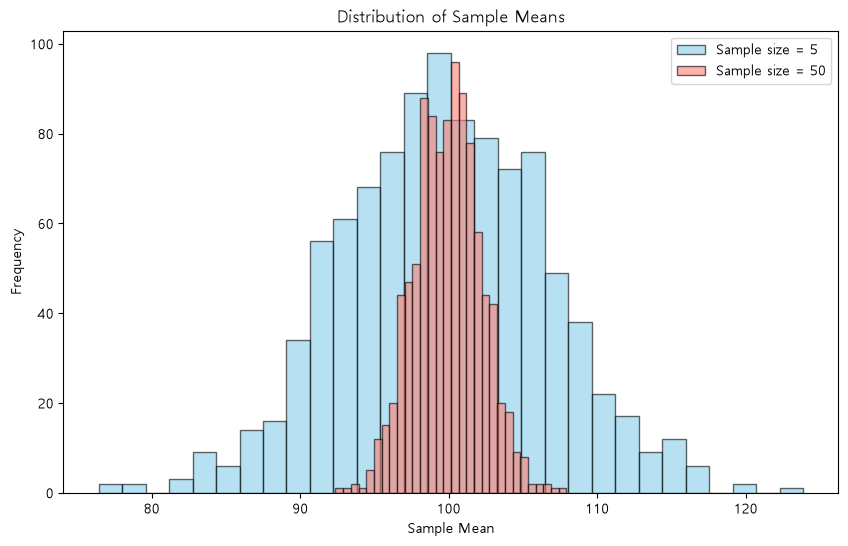

표본 크기 5 - 표본평균의 표준편차: 6.87
표본 크기 50 - 표본평균의 표준편차: 2.23


In [22]:
# 아래를 수행해 보세요:
np.random.seed(42)

# 모집단 생성
population = np.random.normal(100, 15, 100000)

# 표본 크기 5, 50에서 각각 1000번 표본평균 추출
sample_means_5 = [np.random.choice(population, 5, replace=False).mean() for _ in range(1000)]
sample_means_50 = [np.random.choice(population, 50, replace=False).mean() for _ in range(1000)]

# 히스토그램 비교
plt.figure(figsize=(10, 6))
plt.hist(sample_means_5, bins=30, alpha=0.6, label='Sample size = 5', color='skyblue', edgecolor='black')
plt.hist(sample_means_50, bins=30, alpha=0.6, label='Sample size = 50', color='salmon', edgecolor='black')
plt.title('Distribution of Sample Means')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"표본 크기 5 - 표본평균의 표준편차: {np.std(sample_means_5):.2f}")
print(f"표본 크기 50 - 표본평균의 표준편차: {np.std(sample_means_50):.2f}")

**🧠 데이터를 어떻게 읽을까요?**

1. **표본 크기가 다를 때 표본 평균 분포는 어떻게 달라졌나요?**
2. **왜 표본 크기가 중요할까요?**
3. **이 개념은 실제로 어디에 활용될 수 있을까요?**

In [23]:
# 데이터를 어떻게 읽을까요?
std_5 = np.std(sample_means_5)
std_50 = np.std(sample_means_50)

print("[1번문제]")
print(f"표본 크기 5일 때 표본평균의 표준편차는 {std_5:.2f}, 표본 크기 50일 때는 {std_50:.2f}로,")
print(f"표본 크기가 커질수록 표본평균의 분포가 평균(100) 주위로 더 좁게 몰리는 것을 확인할 수 있다.")
print(f"히스토그램에서도 표본 크기 5는 넓게 퍼져있는 반면, 표본 크기 50은 훨씬 뾰족하고 좁은 분포를 보이고 있다.")
print()
print("[2번문제]")
print("표본 크기가 중요한 이유는, 표본이 클수록 표본평균이 모집단 평균에 더 가깝고 안정적으로(분산이 낮음) 수렴하기 때문이다.")
print("이는 표본평균의 표준오차(SE = 표준편차/√n)가 표본 크기 n이 커질수록 작아지는 원리에 따른 것으로,")
print("작은 표본은 우연에 의해 극단적인 평균이 나올 위험이 크지만, 큰 표본은 그런 변동성이 줄어드는 것이다.")
print()
print("[3번문제]")
print("이 개념은 여론조사나 설문조사에서 표본 크기를 정할 때, 신뢰구간과 오차범위를 계산하는 데 활용된다.")
print("또한 품질관리에서 제품 일부를 추출해 전체 품질을 추정할 때, 표본 크기를 늘릴수록 추정이 더 정확해진다는 근거로 쓰인다.")
print("의약품 임상시험이나 A/B 테스트에서도 충분한 표본 크기를 확보해야 결과의 신뢰도가 높아진다는 원리로 이어진다.")

[1번문제]
표본 크기 5일 때 표본평균의 표준편차는 6.87, 표본 크기 50일 때는 2.23로,
표본 크기가 커질수록 표본평균의 분포가 평균(100) 주위로 더 좁게 몰리는 것을 확인할 수 있다.
히스토그램에서도 표본 크기 5는 넓게 퍼져있는 반면, 표본 크기 50은 훨씬 뾰족하고 좁은 분포를 보이고 있다.

[2번문제]
표본 크기가 중요한 이유는, 표본이 클수록 표본평균이 모집단 평균에 더 가깝고 안정적으로(분산이 낮음) 수렴하기 때문이다.
이는 표본평균의 표준오차(SE = 표준편차/√n)가 표본 크기 n이 커질수록 작아지는 원리에 따른 것으로,
작은 표본은 우연에 의해 극단적인 평균이 나올 위험이 크지만, 큰 표본은 그런 변동성이 줄어드는 것이다.

[3번문제]
이 개념은 여론조사나 설문조사에서 표본 크기를 정할 때, 신뢰구간과 오차범위를 계산하는 데 활용된다.
또한 품질관리에서 제품 일부를 추출해 전체 품질을 추정할 때, 표본 크기를 늘릴수록 추정이 더 정확해진다는 근거로 쓰인다.
의약품 임상시험이나 A/B 테스트에서도 충분한 표본 크기를 확보해야 결과의 신뢰도가 높아진다는 원리로 이어진다.


# 문제 11. 단순 선형 회귀 분석

**📘 문제**

- 공부 시간과 성적 간의 관계를 회귀 분석으로 확인해봅시다.

In [25]:
# 데이터 생성
from sklearn.linear_model import LinearRegression

np.random.seed(505)
study_time = np.random.normal(5, 2, 100)
score = 50 + study_time * 8 + np.random.normal(0, 5, 100)
df11 = pd.DataFrame({'study_time': study_time, 'score': score})
df11.head(10)

,study_time,score
0,4.078149,82.712993
1,6.557984,100.104348
2,3.685629,74.159668
3,3.795957,87.208510
4,3.029379,80.639665
5,4.334288,86.435217
6,5.795682,99.324640
7,7.894332,111.730741
8,5.559506,93.953229
9,2.519468,79.644323


**📌 아래를 수행해 보세요:**

1. 공부 시간(`study_time`)과 성적(`score`)간의 관계를 단순 선형 회귀모델로 분석합니다.
2. 회귀 모델을 학습하고, 기울기(계수)와 절편을 출력해 봅시다.
3. 산점도 위에 회귀선을 시각화해 봅시다.

    study_time
0     4.078149
1     6.557984
2     3.685629
3     3.795957
4     3.029379
..         ...
95    8.296765
96    7.607348
97    4.705227
98    6.953105
99    4.459529

[100 rows x 1 columns]
0      82.712993
1     100.104348
2      74.159668
3      87.208510
4      80.639665
         ...    
95    112.110721
96    106.951670
97     83.706448
98    105.456082
99     88.849970
Name: score, Length: 100, dtype: float64
기울기(계수): 7.91
절편: 51.61


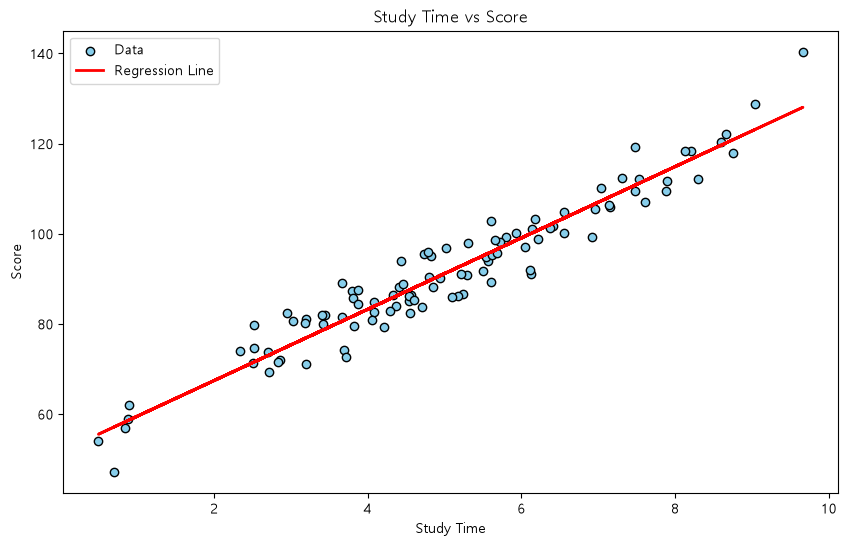

In [ ]:
# 아래를 수행해 보세요:
# 회귀모델 학습
X = df11[['study_time']]
y = df11['score']
print(X)
print(y)

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

print(f"기울기(계수): {slope:.2f}")
print(f"절편: {intercept:.2f}")

# 산점도 + 회귀선 시각화
plt.figure(figsize=(10, 6))
plt.scatter(df11['study_time'], df11['score'], color='skyblue', edgecolor='black', label='Data')
plt.plot(df11['study_time'], model.predict(X), color='red', linewidth=2, label='Regression Line')
plt.title('Study Time vs Score')
plt.xlabel('Study Time')
plt.ylabel('Score')
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

1. 공부 시간이 성적에 어떤 영향을 주었나요?
2. 회귀선은 데이터를 잘 설명하고 있나요?
3. 이 회귀식을 현실에 적용할 수 있을까요?
4. 선형 회귀분석은 언제 활용할 수 있을까요?

In [28]:
# 데이터를 어떻게 읽을까요?
r_squared = model.score(X, y)
print("[1번문제]")
print(f"회귀식은 score = {slope:.2f} * study_time + {intercept:.2f}로 나타났다.")
print(f"기울기가 {slope:.2f}이므로, 공부 시간이 1시간 늘어날 때마다 성적이 평균적으로 약 {slope:.2f}점 상승하는 것으로 해석할 수 있다.")
print(f"기울기가 양수라는 것은 공부 시간과 성적 사이에 양의 관계가 있음을 의미한다.")
print()
print("[2번문제]")
print(f"결정계수(R²)는 {r_squared:.3f}로, 이는 성적 변동의 약 {r_squared*100:.1f}%가 공부 시간만으로 설명된다는 뜻이다.")
if r_squared > 0.7:
    print("R²가 높은 편이므로 회귀선이 데이터를 비교적 잘 설명하고 있다고 볼 수 있다.")
else:
    print("R²가 낮은 편이므로 공부 시간 외에 다른 요인들도 성적에 영향을 미칠 가능성이 있다.")
print()
print("[3번문제]")
print("이 회귀식은 공부 시간과 성적 사이의 대략적인 경향을 파악하는 데 활용할 수 있지만,")
print("실제 현실에서는 학생의 개인차, 공부 방법, 시험 난이도 등 다른 변수들이 존재하므로")
print("이 식만으로 특정 학생의 성적을 정확히 예측하기에는 한계가 있다.")
print("또한 이 데이터는 상관관계를 보여줄 뿐, 공부 시간이 성적을 직접적으로 '원인'으로서 높인다고 단정할 수는 없을 것이다.")
print()
print("[4번문제]")
print("선형 회귀분석은 독립변수와 종속변수 사이에 대략적인 직선 관계가 있다고 판단될 때,")
print("그 관계의 방향과 크기를 수치화하거나, 새로운 입력값에 대한 결과를 예측하고 싶을 때 활용할 수 있다.")
print("예를 들어 광고비 대비 매출 예측, 온도에 따른 판매량 예측처럼 하나의 변수로 다른 변수를 설명/예측하는 상황에 적합하다.")

[1번문제]
회귀식은 score = 7.91 * study_time + 51.61로 나타났다.
기울기가 7.91이므로, 공부 시간이 1시간 늘어날 때마다 성적이 평균적으로 약 7.91점 상승하는 것으로 해석할 수 있다.
기울기가 양수라는 것은 공부 시간과 성적 사이에 양의 관계가 있음을 의미한다.

[2번문제]
결정계수(R²)는 0.927로, 이는 성적 변동의 약 92.7%가 공부 시간만으로 설명된다는 뜻이다.
R²가 높은 편이므로 회귀선이 데이터를 비교적 잘 설명하고 있다고 볼 수 있다.

[3번문제]
이 회귀식은 공부 시간과 성적 사이의 대략적인 경향을 파악하는 데 활용할 수 있지만,
실제 현실에서는 학생의 개인차, 공부 방법, 시험 난이도 등 다른 변수들이 존재하므로
이 식만으로 특정 학생의 성적을 정확히 예측하기에는 한계가 있다.
또한 이 데이터는 상관관계를 보여줄 뿐, 공부 시간이 성적을 직접적으로 '원인'으로서 높인다고 단정할 수는 없을 것이다.

[4번문제]
선형 회귀분석은 독립변수와 종속변수 사이에 대략적인 직선 관계가 있다고 판단될 때,
그 관계의 방향과 크기를 수치화하거나, 새로운 입력값에 대한 결과를 예측하고 싶을 때 활용할 수 있다.
예를 들어 광고비 대비 매출 예측, 온도에 따른 판매량 예측처럼 하나의 변수로 다른 변수를 설명/예측하는 상황에 적합하다.


# 문제 12. A/B 테스트 해석

**📘 문제**

- 두 그룹의 전환율 차이를 계산하고 해석해봅시다.

In [29]:
# 데이터 생성
np.random.seed(606)
group_a = np.random.binomial(1, 0.12, 1000)
group_b = np.random.binomial(1, 0.15, 1000)

**📌 아래를 수행해 보세요:**

1. A 그룹과 B 그룹의 전환 데이터를 살펴봅니다.
2. 각 그룹의 전환율을 계산하고, 차이를 확인합니다.
3. 이 차이가 우연인지, 의미 있는 차이인지 생각해 봅시다.

In [31]:
# 아래를 수행해 보세요:
from scipy import stats

# 전환율 계산
conv_rate_a = group_a.mean()
conv_rate_b = group_b.mean()

print(f"A 그룹 전환율: {conv_rate_a:.4f} ({conv_rate_a*100:.2f}%)")
print(f"B 그룹 전환율: {conv_rate_b:.4f} ({conv_rate_b*100:.2f}%)")
print(f"전환율 차이: {abs(conv_rate_a - conv_rate_b)*100:.2f}%")

# 통계적 유의성 검정 (독립표본 t-검정)
t_stat, p_value = stats.ttest_ind(group_a, group_b)
print(f"\nt-통계량: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("p-value < 0.05이므로, 이 차이는 통계적으로 유의미하다고 볼 수 있다 (우연이 아닐 가능성이 높음).")
else:
    print("p-value >= 0.05이므로, 이 차이가 통계적으로 유의미하다고 보기 어렵다 (우연일 가능성을 배제할 수 없음).")

A 그룹 전환율: 0.1310 (13.10%)
B 그룹 전환율: 0.1330 (13.30%)
전환율 차이: 0.20%

t-통계량: -0.1321
p-value: 0.8950
p-value >= 0.05이므로, 이 차이가 통계적으로 유의미하다고 보기 어렵다 (우연일 가능성을 배제할 수 없음).


**🧠 데이터를 어떻게 읽을까요?**

1. 두 그룹의 전환율 차이는 얼마나 되나요?
2. 차이가 '의미 있다'는 건 무엇을 뜻하나요?
3. 이 실험 결과로 어떤 결정을 내릴 수 있을까요?
4. A/B 테스트는 현실에서 어떻게 쓰일까요?

In [ ]:
# 데이터를 어떻게 읽을까요?
diff_pct = abs(conv_rate_a - conv_rate_b) * 100

print("[1번문제]")
print(f"A 그룹 전환율은 {conv_rate_a*100:.2f}%, B 그룹 전환율은 {conv_rate_b*100:.2f}%로, 차이는 약 {diff_pct:.2f}%이다.")
print()
print("[2번문제]")
print("'의미 있는 차이'라는 것은 이 차이가 단순히 우연한 표본 변동 때문이 아니라,")
print("실제로 두 그룹 사이에 근본적인 차이가 존재한다는 것을 뜻한다.")
print(f"이번 결과에서 p-value는 {p_value:.4f}로, 이는 '두 그룹의 전환율이 실제로 같다'는 가정 하에")
if p_value < 0.05:
    print("p-value가 0.05보다 작으므로, 이 차이가 우연일 가능성은 낮고 통계적으로 유의미하다고 판단할 수 있다.")
else:
    print("p-value가 0.05보다 크므로, 이 차이가 우연히 발생했을 가능성을 배제할 수 없다.")
print()
print("[3번문제]")
print("이 실험 결과를 바탕으로, 만약 차이가 통계적으로 유의미하다면 전환율이 더 높은 그룹(B)의 방식을 채택하는 결정을 내릴수있다.")
print("반대로 유의미하지 않다면, 아직 어느 쪽이 더 낫다고 단정할 수 없으므로 표본을 더 모으거나 실험을 연장해서 p-value를 다시 보거나,")
print("전환율을 유의하게 차이나도록 하는 다른 요인을 분석할 필요가 있다.")
print()
print("[4번문제]")
print("A/B 테스트는 실제로 웹사이트 버튼 색상, 문구, UI 레이아웃, 이메일 제목 등")
print("두 가지 이상의 버전 중 어느 것이 더 나은 성과(클릭률, 구매전환율 등)를 내는지 검증할 때 널리 사용된다고 한다.")
print("일부 사용자에게는 기존 버전(A)을, 다른 사용자에게는 새 버전(B)을 무작위로 보여준 뒤")
print("전환율 차이가 통계적으로 유의미한지 검정하여 실제 서비스에 어떤 버전을 적용할지 데이터 기반으로 결정한다.")

[1번문제]
A 그룹 전환율은 13.10%, B 그룹 전환율은 13.30%로, 차이는 약 0.20%이다.

[2번문제]
'의미 있는 차이'라는 것은 이 차이가 단순히 우연한 표본 변동 때문이 아니라,
실제로 두 그룹 사이에 근본적인 차이가 존재한다는 것을 뜻한다.
이번 결과에서 p-value는 0.8950로, 이는 '두 그룹의 전환율이 실제로 같다'는 가정 하에
p-value가 0.05보다 크므로, 이 차이가 우연히 발생했을 가능성을 배제할 수 없다.

[3번문제]
이 실험 결과를 바탕으로, 만약 차이가 통계적으로 유의미하다면 전환율이 더 높은 그룹(B)의 방식을 채택하는 결정을 내릴 수 있다.
반대로 유의미하지 않다면, 아직 어느 쪽이 더 낫다고 단정할 수 없으므로 표본을 더 모으거나 실험을 연장해서 p-value를 다시 보거나,
전환율을 유의하게 차이나도록 하는 다른 요인을 분석할 필요가 있다.

[4번문제]
A/B 테스트는 실제로 웹사이트 버튼 색상, 문구, UI 레이아웃, 이메일 제목 등
두 가지 이상의 버전 중 어느 것이 더 나은 성과(클릭률, 구매전환율 등)를 내는지 검증할 때 널리 사용된다고 한다.
일부 사용자에게는 기존 버전(A)을, 다른 사용자에게는 새 버전(B)을 무작위로 보여준 뒤
전환율 차이가 통계적으로 유의미한지 검정하여 실제 서비스에 어떤 버전을 적용할지 데이터 기반으로 결정한다.
